# E0 — the Runge–Kutta objects the RK-PINN must predict

**Purpose.** Before any network exists, build the exact Gauss–Legendre stage states and
endpoints to machine precision, so a trained model has something to be measured against.
Everything plotted here is an *exact* Runge–Kutta object. **No network is trained anywhere
in this notebook**, so every error shown is the integration scheme's, never a model's.

Method: Raissi, Perdikaris & Karniadakis, *Physics-informed neural networks*,
J. Comput. Phys. **378** (2019) 686–707, §3.2. Van der Pol at $\mu=1$, from $y^n=(2,0)$.

Produced by `e0_checks.py` → `results/`, and `paper_figs.py` → `figures/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent / "_shared"))
RESULTS, FIGURES = HERE / "results", HERE / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_EXACT, C_PRIN, C_SPUR = "#33322e", "#2a78d6", "#e34948"


## 1. The tableaux

Gauss–Legendre nodes are roots of the shifted Legendre polynomial; $b$ and $a_{ij}$ follow
from the order conditions $\sum_j b_j c_j^{k-1} = 1/k$ and $\sum_j a_{ij} c_j^{k-1} = c_i^k/k$.
That Vandermonde system is badly ill-conditioned, so `rk_core` solves it at 60 digits with
`mpmath` before casting to float64. Checked against the closed forms at $q=1$ (implicit
midpoint) and $q=2$.

In [2]:
tab = pd.read_csv(RESULTS / "e0_tableaux.csv")
print(f"max |computed - closed form| = {tab.abs_err.max():.2e}")
tab

max |computed - closed form| = 1.11e-16


,q,quantity,value,expected,abs_err
0,1,c[0],0.500000,0.500000,0.000000e+00
1,1,b[0],1.000000,1.000000,0.000000e+00
2,1,A[0],0.500000,0.500000,0.000000e+00
3,2,c[0],0.211325,0.211325,2.775558e-17
4,2,c[1],0.788675,0.788675,1.110223e-16
5,2,b[0],0.500000,0.500000,0.000000e+00
6,2,b[1],0.500000,0.500000,0.000000e+00
7,2,A[0],0.250000,0.250000,0.000000e+00
8,2,A[1],-0.038675,-0.038675,1.387779e-17
9,2,A[2],0.538675,0.538675,0.000000e+00


## 2. Order $2q$, and the reference floor

A $q$-stage Gauss–Legendre scheme has order $2q$. The lines below should have slope
$2q+1$ in a single step (local error), until they hit the accuracy of the Radau
reference solution itself (`rtol = atol = 1e-12`) — which is a *reference* floor,
not machine precision, and not a network's.

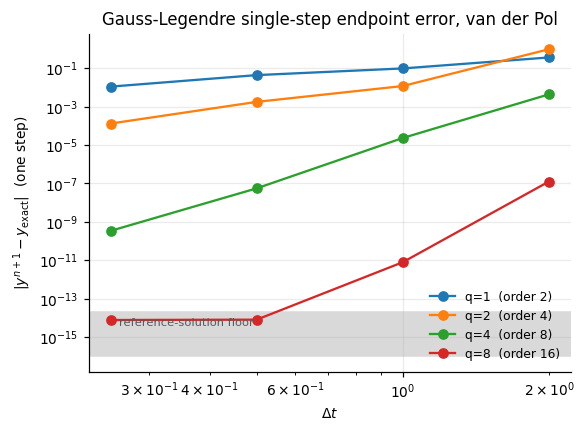

dt,0.25,0.50,1.00,2.00
q,,,,
1,1.10e-02,4.37e-02,9.75e-02,3.64e-01
2,1.31e-04,1.77e-03,1.18e-02,9.77e-01
4,3.38e-10,5.55e-08,2.33e-05,4.37e-03
8,7.71e-15,8.04e-15,7.91e-12,1.26e-07


In [3]:
conv = pd.read_csv(RESULTS / "e0_convergence.csv")

fig, ax = plt.subplots(figsize=(5.4, 4.0))
for q, g in conv.groupby("q"):
    g = g.sort_values("dt")
    ax.loglog(g.dt, g.endpoint_err, "o-", label=f"q={q}  (order {2*q})")
ax.axhspan(1e-16, 2e-14, color="0.85", zorder=0)
ax.text(0.26, 4e-15, "reference-solution floor", fontsize=7.5, color="0.35")
ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel(r"$|y^{n+1} - y_{\rm exact}|$  (one step)")
ax.set_title("Gauss-Legendre single-step endpoint error, van der Pol")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(FIGURES / "e0_convergence.png"); plt.show()

conv.pivot(index="q", columns="dt", values="endpoint_err").map(lambda v: f"{v:.2e}")

### Observed order

Fitted on the two smallest steps, away from the reference floor. Expect $\approx 2q+1$
for a single step, so $q=1 \to 3$, $q=2 \to 5$. Large $q$ has already hit the floor and
the fit is meaningless there — which the table below shows honestly rather than hiding.

In [4]:
rows = []
for q, g in conv.groupby("q"):
    g = g.sort_values("dt").head(2)
    p = np.polyfit(np.log(g.dt), np.log(g.endpoint_err), 1)[0]
    floored = bool((g.endpoint_err < 5e-14).any())
    rows.append(dict(q=q, expected_local_order=2*q+1, observed=p,
                     at_reference_floor=floored))
pd.DataFrame(rows)

,q,expected_local_order,observed,at_reference_floor
0,1,3,1.991827,False
1,2,5,3.750479,False
2,4,9,7.356499,False
3,8,17,0.061505,True


## 3. The reconstruction identity — this *is* the loss

Rearranging each of the $q+1$ Runge–Kutta relations gives an expression for the one state
already known, $y^n$:

$$y^n_i := Y_i - \Delta t \sum_j a_{ij} f(Y_j), \qquad
  y^n_{q+1} := y^{n+1} - \Delta t \sum_j b_j f(Y_j)$$

At the converged stage solution every one of them must return $y^n$. The RK-PINN loss is
exactly the squared failure of this identity. Here it is evaluated at the *exact* answer,
so it should be zero to machine precision — and it is.

In [5]:
rec = pd.read_csv(RESULTS / "e0_reconstruction.csv")
print(f"max deviation of any reconstruction from y^n = {rec.dev.max():.2e}")
print(f"max stage-solve residual                     = {conv.stage_residual.max():.2e}")
rec[(rec.q == 4) & (rec.dt == 1.0)]

max deviation of any reconstruction from y^n = 3.33e-16
max stage-solve residual                     = 3.33e-16


,q,dt,relation,y1,y2,dev
30,4,1.0,1,2.0,-1.387779e-17,1.387779e-17
31,4,1.0,2,2.0,0.000000e+00,0.000000e+00
32,4,1.0,3,2.0,-1.110223e-16,1.110223e-16
33,4,1.0,4,2.0,0.000000e+00,0.000000e+00
34,4,1.0,5,2.0,0.000000e+00,0.000000e+00


## 4. The two figures for the write-up

`paper_figs.py` emits hand-rolled SVG (Notion's attachment API takes the file inline as a
UTF-8 string, so matplotlib's per-glyph outlines are far too large to transcribe).

- `figures/fig_models.svg` — the continuous-time model (§3.1) beside the discrete-time
  model (§3.2), with the $q+1$ dashed arrows collapsing back onto $y^n$: the loss, drawn.
- `figures/fig_stages.svg` — order $2q$, and a single $\Delta t = 2$ step where explicit
  RK4 is unstable while Gauss–Legendre is not.

fig_models.svg: 10.5 KiB


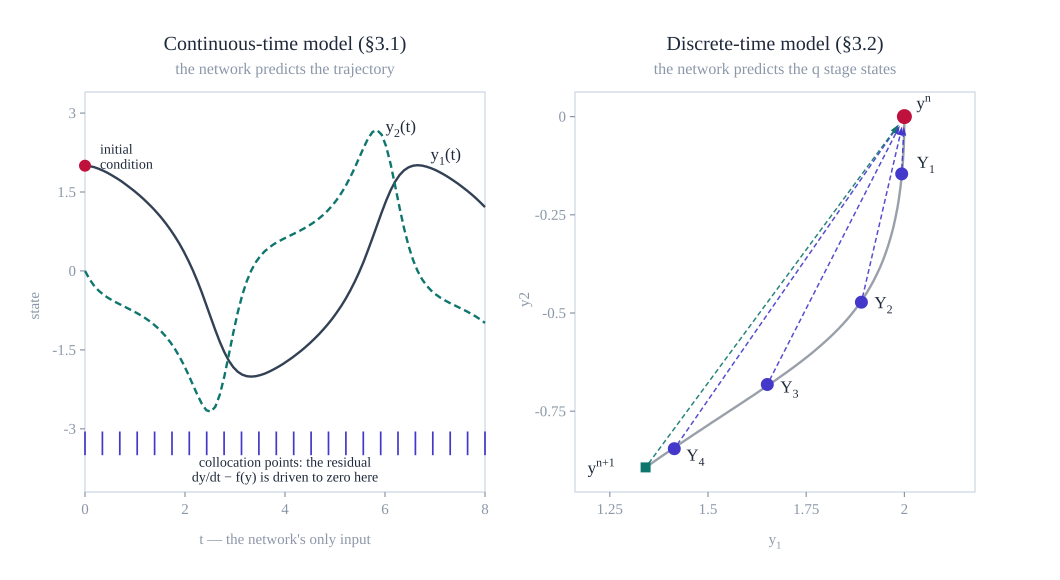

fig_stages.svg: 9.4 KiB


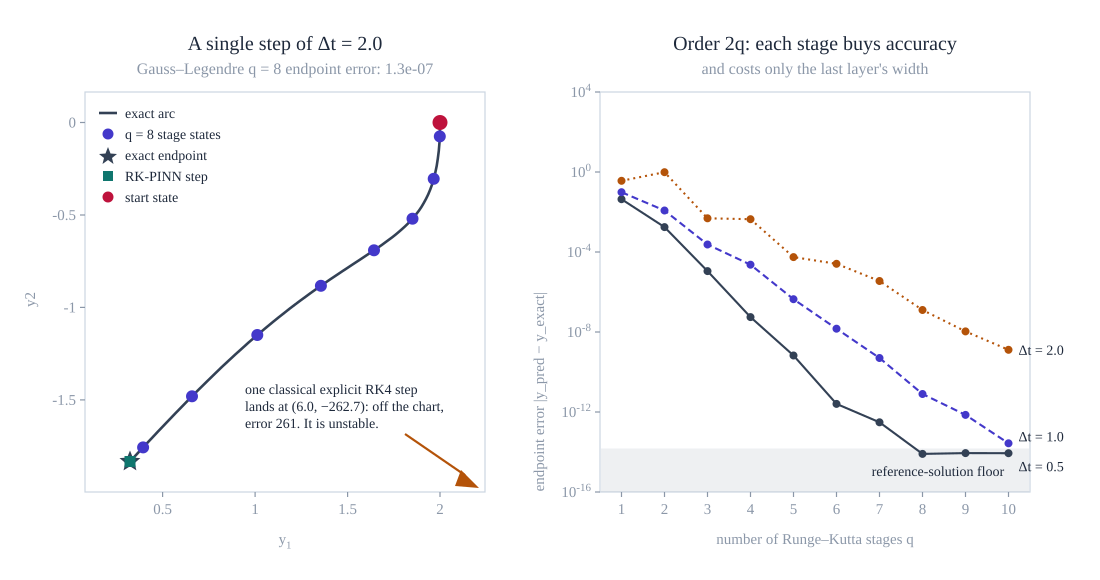

In [6]:
from IPython.display import SVG, display
for nm in ("fig_models", "fig_stages"):
    p = FIGURES / f"{nm}.svg"
    print(f"{p.name}: {p.stat().st_size/1024:.1f} KiB")
    display(SVG(filename=str(p)))